<a href="https://colab.research.google.com/github/ManoloVM21/MachineLearningTeam4/blob/main/RoadSigns_Manolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Definir el problema

Detectar señales de transito. 43 clases de selañles. No hay la misma cantidad de imagenes de cada clase.
Las señales se diferencian por: Forma, Color, Detalles internos finos.

Objetivo, alcanzar un F1 de 1.00 -> con clases desbalanciadas accuracy es engañoso.
-> Modelo debe de escoger 1 entre 43 distintas clases de acuerdo con la probabilidad (activation = 'softmax')

# 2) Inspect the data structure


In [ ]:
!echo "Downloading files..."
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training1.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/training2.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout.zip
!wget -q https://github.com/byui-cse/cse450-course/raw/master/data/roadsigns/mini_holdout_answers.csv

!echo "Unzipping files..."
!unzip -q /content/training1.zip
!unzip -q /content/training2.zip
!unzip -q /content/holdout.zip
!unzip -q /content/mini_holdout.zip

# Combine the two traning directories
!echo "Merging training data..."
!mkdir /content/training
!mv /content/training1/* /content/training
!mv /content/training2/* /content/training

# Cleanup
!echo "Cleaning up..."
!rmdir /content/training1
!rmdir /content/training2
!rm training1.zip
!rm training2.zip
!rm holdout.zip
!rm mini_holdout.zip

!echo "Data ready."

Unzipping files...
Merging training data...
Cleaning up...
Data ready.


In [ ]:
import os

print(os.listdir('/content')[:20])
print(os.listdir('/content/training')[:20])

['.config', 'holdout', 'mini_holdout', 'mini_holdout_answers.csv', 'training', 'sample_data']
['00035', '00019', '00033', '00002', '00040', '00027', '00038', '00031', '00029', '00034', '00021', '00032', '00018', '00008', '00041', '00007', '00012', '00013', '00015', '00010']


In [ ]:
first_folders = os.listdir('/content/training')[:5]
for folder in first_folders:
    path = os.path.join('/content/training', folder)
    print(folder, "->", os.path.isdir(path))

00035 -> True
00019 -> True
00033 -> True
00002 -> True
00040 -> True


Conclusion:
 * There are folders named 'training','holdout', and 'holdout_mini'.

 * Training esta organizado por carpetas de cada clase.

se puede usar flow_from_directory()
es un problema de clasificacion directa
Keras asignara automaticamente un indice numerico para cada carpeta

*Data is ready for splitting*

## How many classes? Img per class? Desbalance leve o fuerte? Que formato tienen las imagenes? Problemas con datos vacios o raros?

In [ ]:
import os

training_dir = '/content/training'

class_names = sorted(os.listdir(training_dir))
print("Número de clases:", len(class_names))
print("Primeras 10 clases:", class_names[:10])

class_counts = {}
for class_name in class_names:
    class_path = os.path.join(training_dir, class_name)
    if os.path.isdir(class_path):
        class_counts[class_name] = len(os.listdir(class_path))

print("\nPRiemras 10 Clases con conteos:")
for i, (cls, count) in enumerate(class_counts.items()):
    if i >= 10:
        break
    print(cls, "->", count)

Número de clases: 43
Primeras 10 clases: ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009']

PRiemras 10 Clases con conteos:
00000 -> 210
00001 -> 2220
00002 -> 2250
00003 -> 1410
00004 -> 1980
00005 -> 1860
00006 -> 420
00007 -> 1440
00008 -> 1410
00009 -> 1470


In [ ]:
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)

print("\nClase con menos imágenes:", min_class, "->", class_counts[min_class])
print("Clase con más imágenes:", max_class, "->", class_counts[max_class])


Clase con menos imágenes: 00000 -> 210
Clase con más imágenes: 00002 -> 2250


# 3) Cargar los datos

In [ ]:
# Import libraries
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import os
from sklearn.model_selection import train_test_split
from collections import Counter

In [ ]:
training_dir = '/content/training/'
image_size = (100, 100)

# 4) Preparar Train/Validation


In [ ]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    training_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    training_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 39209 files belonging to 43 classes.
Using 31368 files for training.
Found 39209 files belonging to 43 classes.
Using 7841 files for validation.


In [ ]:
class_names = train_ds.class_names
print("Número de clases:", len(class_names))
print("Primeras 10 clases:", class_names[:10])
for images, labels in train_ds.take(1):
    print("Shape de imágenes:", images.shape)
    print("Shape de labels:", labels.shape)
    print("Primeros 10 labels del batch:", labels[:10].numpy())

Número de clases: 43
Primeras 10 clases: ['00000', '00001', '00002', '00003', '00004', '00005', '00006', '00007', '00008', '00009']
Shape de imágenes: (32, 100, 100, 3)
Shape de labels: (32,)
Primeros 10 labels del batch: [ 7 10  4  4 17 24 13  2 20 11]


# 5) Balancear los datos

Se pueden hacer de 3 formas: class_weights, augmentation, oversampling

1st try with class_weights
-> Las clases con menos cantidad de imagenes costaran más accuracy

In [ ]:

train_labels = np.concatenate([y.numpy() for x, y in train_ds], axis=0)

print("Total labels en train:", len(train_labels))
print("Primeros labels:", train_labels[:10])

Total labels en train: 31368
Primeros labels: [28 15 25  6  4 16  9  5 38 13]


In [ ]:

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class weights:")
print(class_weights)

Class weights:
{0: np.float64(4.3945082656206225), 1: np.float64(0.4116751535513675), 2: np.float64(0.4039249014911535), 3: np.float64(0.6589777525682233), 4: np.float64(0.45507696325204194), 5: np.float64(0.4928975487115022), 6: np.float64(2.1582496215769917), 7: np.float64(0.6566051954032612), 8: np.float64(0.6387814116401255), 9: np.float64(0.6256332522238621), 10: np.float64(0.44808868064682017), 11: np.float64(0.6954131287826724), 12: np.float64(0.4339609590083422), 13: np.float64(0.422891809908999), 14: np.float64(1.156082998562636), 15: np.float64(1.539005004415661), 16: np.float64(2.2376943929233843), 17: np.float64(0.8168962733404516), 18: np.float64(0.7630631507249197), 19: np.float64(4.3945082656206225), 20: np.float64(2.58683819891143), 21: np.float64(2.7018087855297157), 22: np.float64(2.368468740561764), 23: np.float64(1.8056642873589686), 24: np.float64(3.440982887231242), 25: np.float64(0.6166427490219977), 26: np.float64(1.4796924383225625), 27: np.float64(3.6657707140

In [ ]:
min_weight = min(class_weights.values())
max_weight = max(class_weights.values())

print("Peso mínimo:", min_weight)
print("Peso máximo:", max_weight)

Peso mínimo: 0.4039249014911535
Peso máximo: 4.3945082656206225


In [ ]:
for images, labels in train_ds.take(1):
    print(images.dtype)
    print(tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy())
    print(labels[:10].numpy())

<dtype: 'float32'>
0.0 255.0
[ 9 12  5  4  5 10 13 33 25 29]


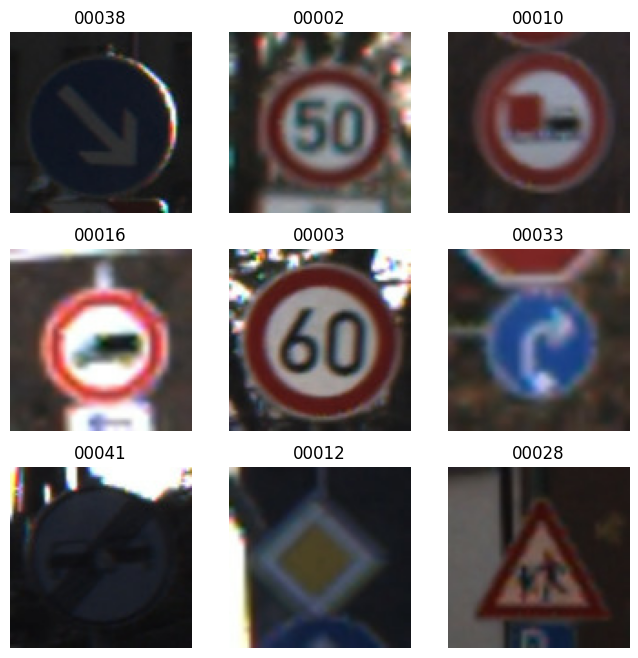

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(8,8))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.show()

# 6) Elegir estructura base

EfficientNetB0
MobileNetV2
ResNet50

En este caso eligire EfficientNetB0

Input

Capa de normalización/rescaling

Data augmentation ligera

EfficientNetB0 sin la cabeza final

GlobalAveragePooling2D

Dropout

Dense final con softmax

In [ ]:
num_classes = len(class_names)

data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.1),
], name="data_augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(100, 100, 3)
)

#No conviene modificar el modelo en primer instancia, luego vamos a ver
base_model.trainable = True

inputs = keras.Input(shape=(100, 100, 3))
x = layers.Rescaling(1./255)(inputs)
x = data_augmentation(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,104,654 (15.66 MB)

 Trainable params: 4,062,631 (15.50 MB)

 Non-trainable params: 42,023 (164.16 KB)

# 7) Entrenar la cabeza del modelo

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 164s 123ms/step - accuracy: 0.8655 - loss: 0.4499 - val_accuracy: 0.0406 - val_loss: 330.6742 - learning_rate: 0.0010
Epoch 2/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 116s 118ms/step - accuracy: 0.9612 - loss: 0.1265 - val_accuracy: 0.0555 - val_loss: 879.7977 - learning_rate: 0.0010
Epoch 3/15
981/981 ━━━━━━━━━━━━━━━━━━━━ 115s 118ms/step - accuracy: 0.9737 - loss: 0.0759 - val_accuracy: 0.0307 - val_loss: 5.1594 - learning_rate: 0.0010
Epoch 4/15
387/981 ━━━━━━━━━━━━━━━━━━━━ 1:07 113ms/step - accuracy: 0.9842 - loss: 0.0325

KeyboardInterrupt: 

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

num_classes = len(class_names)

base_model = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(100, 100, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(100, 100, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

simple_model = keras.Model(inputs, outputs)

simple_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

simple_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        55,083 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,104,654 (15.66 MB)

 Trainable params: 55,083 (215.17 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
simple_history = simple_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 75s 49ms/step - accuracy: 0.6552 - loss: 1.2292 - val_accuracy: 0.8077 - val_loss: 0.6865
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.8215 - loss: 0.6273 - val_accuracy: 0.8717 - val_loss: 0.4770
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8683 - loss: 0.4736 - val_accuracy: 0.9017 - val_loss: 0.3770
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8929 - loss: 0.3863 - val_accuracy: 0.9151 - val_loss: 0.3215
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - accuracy: 0.9080 - loss: 0.3314 - val_accuracy: 0.9254 - val_loss: 0.2790


In [ ]:
simple_model_w = keras.models.clone_model(simple_model)
simple_model_w.set_weights(simple_model.get_weights())

simple_model_w.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_w = simple_model_w.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights
)

Epoch 1/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 58s 39ms/step - accuracy: 0.7700 - loss: 0.6681 - val_accuracy: 0.8333 - val_loss: 0.5829
Epoch 2/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.8294 - loss: 0.4714 - val_accuracy: 0.8546 - val_loss: 0.4888
Epoch 3/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8533 - loss: 0.3948 - val_accuracy: 0.8754 - val_loss: 0.4297
Epoch 4/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.8697 - loss: 0.3422 - val_accuracy: 0.8913 - val_loss: 0.3787
Epoch 5/5
981/981 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.8819 - loss: 0.3017 - val_accuracy: 0.8967 - val_loss: 0.3566


# EFFICIENTNETBO0

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ─────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32        # EfficientNet es más liviano que ResNet, podemos subir a 32
NUM_CLASSES = 43
DATASET_DIR = "/content/training"
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

# ── 1) RECOLECTAR RUTAS Y LABELS ───────────────────────────────────────
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}

image_paths, labels = [], []
for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels      = np.array(labels)
print(f"Total imágenes: {len(image_paths)} | Clases: {len(class_names)}")

# ── 2) SPLIT ESTRATIFICADO ─────────────────────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# ── 3) PREPROCESAMIENTO ────────────────────────────────────────────────
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # ✅ EfficientNet acepta [0, 255] — NO necesita preprocess_input externo
    return image, label

def augment(image, label):
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # ❌ Sin flip horizontal — cambia el significado de la señal
    return image, label

# ── 4) PIPELINES TF.DATA ───────────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)

# ── 5) CLASS WEIGHTS ───────────────────────────────────────────────────
cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(cw_array))

# ── 6) BUILD MODEL ─────────────────────────────────────────────────────
def build_model():
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inputs, outputs), base_model

# ── 7) EVALUACIÓN COMPLETA ─────────────────────────────────────────────
def evaluate_model(model, dataset, labels_true, title="Evaluación"):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(classification_report(labels_true, y_pred,
                                 target_names=class_names, digits=3))

    f1_macro    = f1_score(labels_true, y_pred, average="macro")
    f1_weighted = f1_score(labels_true, y_pred, average="weighted")
    print(f"  Macro F1:    {f1_macro:.4f}")
    print(f"  Weighted F1: {f1_weighted:.4f}")

    cm = confusion_matrix(labels_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.ylabel("Real"); plt.xlabel("Predicho")
    plt.tight_layout(); plt.show()

    return f1_macro, f1_weighted

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO A: Sin class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🔵 EXPERIMENTO A: Sin class_weight")
model_a, base_a = build_model()

print("  → Fase 1: entrenando cabeza")
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

print("  → Fase 2: fine-tuning")
base_a.trainable = True
for layer in base_a.layers[:-20]:
    layer.trainable = False

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_a, f1_w_a = evaluate_model(model_a, val_ds, val_labels, "EfficientNetB0 — Sin class_weight")

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO B: Con class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🟠 EXPERIMENTO B: Con class_weight")
model_b, base_b = build_model()

print("  → Fase 1: entrenando cabeza")
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

print("  → Fase 2: fine-tuning")
base_b.trainable = True
for layer in base_b.layers[:-20]:
    layer.trainable = False

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_b, f1_w_b = evaluate_model(model_b, val_ds, val_labels, "EfficientNetB0 — Con class_weight")

# ── RESUMEN COMPARATIVO ────────────────────────────────────────────────
print("\n" + "="*50)
print("  RESUMEN COMPARATIVO — EfficientNetB0")
print("="*50)
print(f"  Sin class_weight → Macro F1: {f1_macro_a:.4f} | Weighted F1: {f1_w_a:.4f}")
print(f"  Con class_weight → Macro F1: {f1_macro_b:.4f} | Weighted F1: {f1_w_b:.4f}")

Total imágenes: 39209
Total clases: 43
Train: 31367
Validation: 7842
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
=== FASE 1: Entrenando cabeza clasificadora ===
Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 112s 159ms/step - accuracy: 0.6674 - loss: 1.0507 - val_accuracy: 0.8804 - val_loss: 0.3878 - learning_rate: 0.0010
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.8369 - loss: 0.4067 - val_accuracy: 0.9246 - val_loss: 0.2384 - learning_rate: 0.0010
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.8672 - loss: 0.3200 - val_accuracy: 0.9438 - val_loss: 0.1722 - learning_rate: 0.0010
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 44s 90ms/step - accuracy: 0.8862 - loss: 0.2627 - val_accuracy: 0.9452 - val_loss: 0.1625 - learning_rate: 0.0010
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - accuracy: 0.8928 - loss: 0.2503 - val_accuracy: 0.9586 - val_loss: 0.1313 - learning_rate: 0.0010
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 43s 88ms/step - accu

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step
Accuracy on Mini Holdout Dataset: 0.8607

Precision (weighted): 0.9021
Recall (weighted): 0.8607
F1-Score (weighted): 0.8645

Classification Report:
              precision    recall  f1-score   support

       00000       0.00      0.00      0.00         0
       00001       0.92      1.00      0.96        11
       00002       0.86      0.75      0.80         8
       00003       1.00      0.50      0.67        10
       00004       0.70      0.78      0.74         9
       00005       0.71      1.00      0.83         5
       00006       1.00      1.00      1.00         3
       00007       1.00      0.88      0.93         8
       00008       0.67      0.67      0.67         6
       00009       1.00      1.00      1.00        10
       00010       0.80      1.00      0.89        12
       00011       0.89      1.00      0.94         8
       00012       1.00      1.00      1.00         7
       00013       1.00      1.00      1.00        10
   

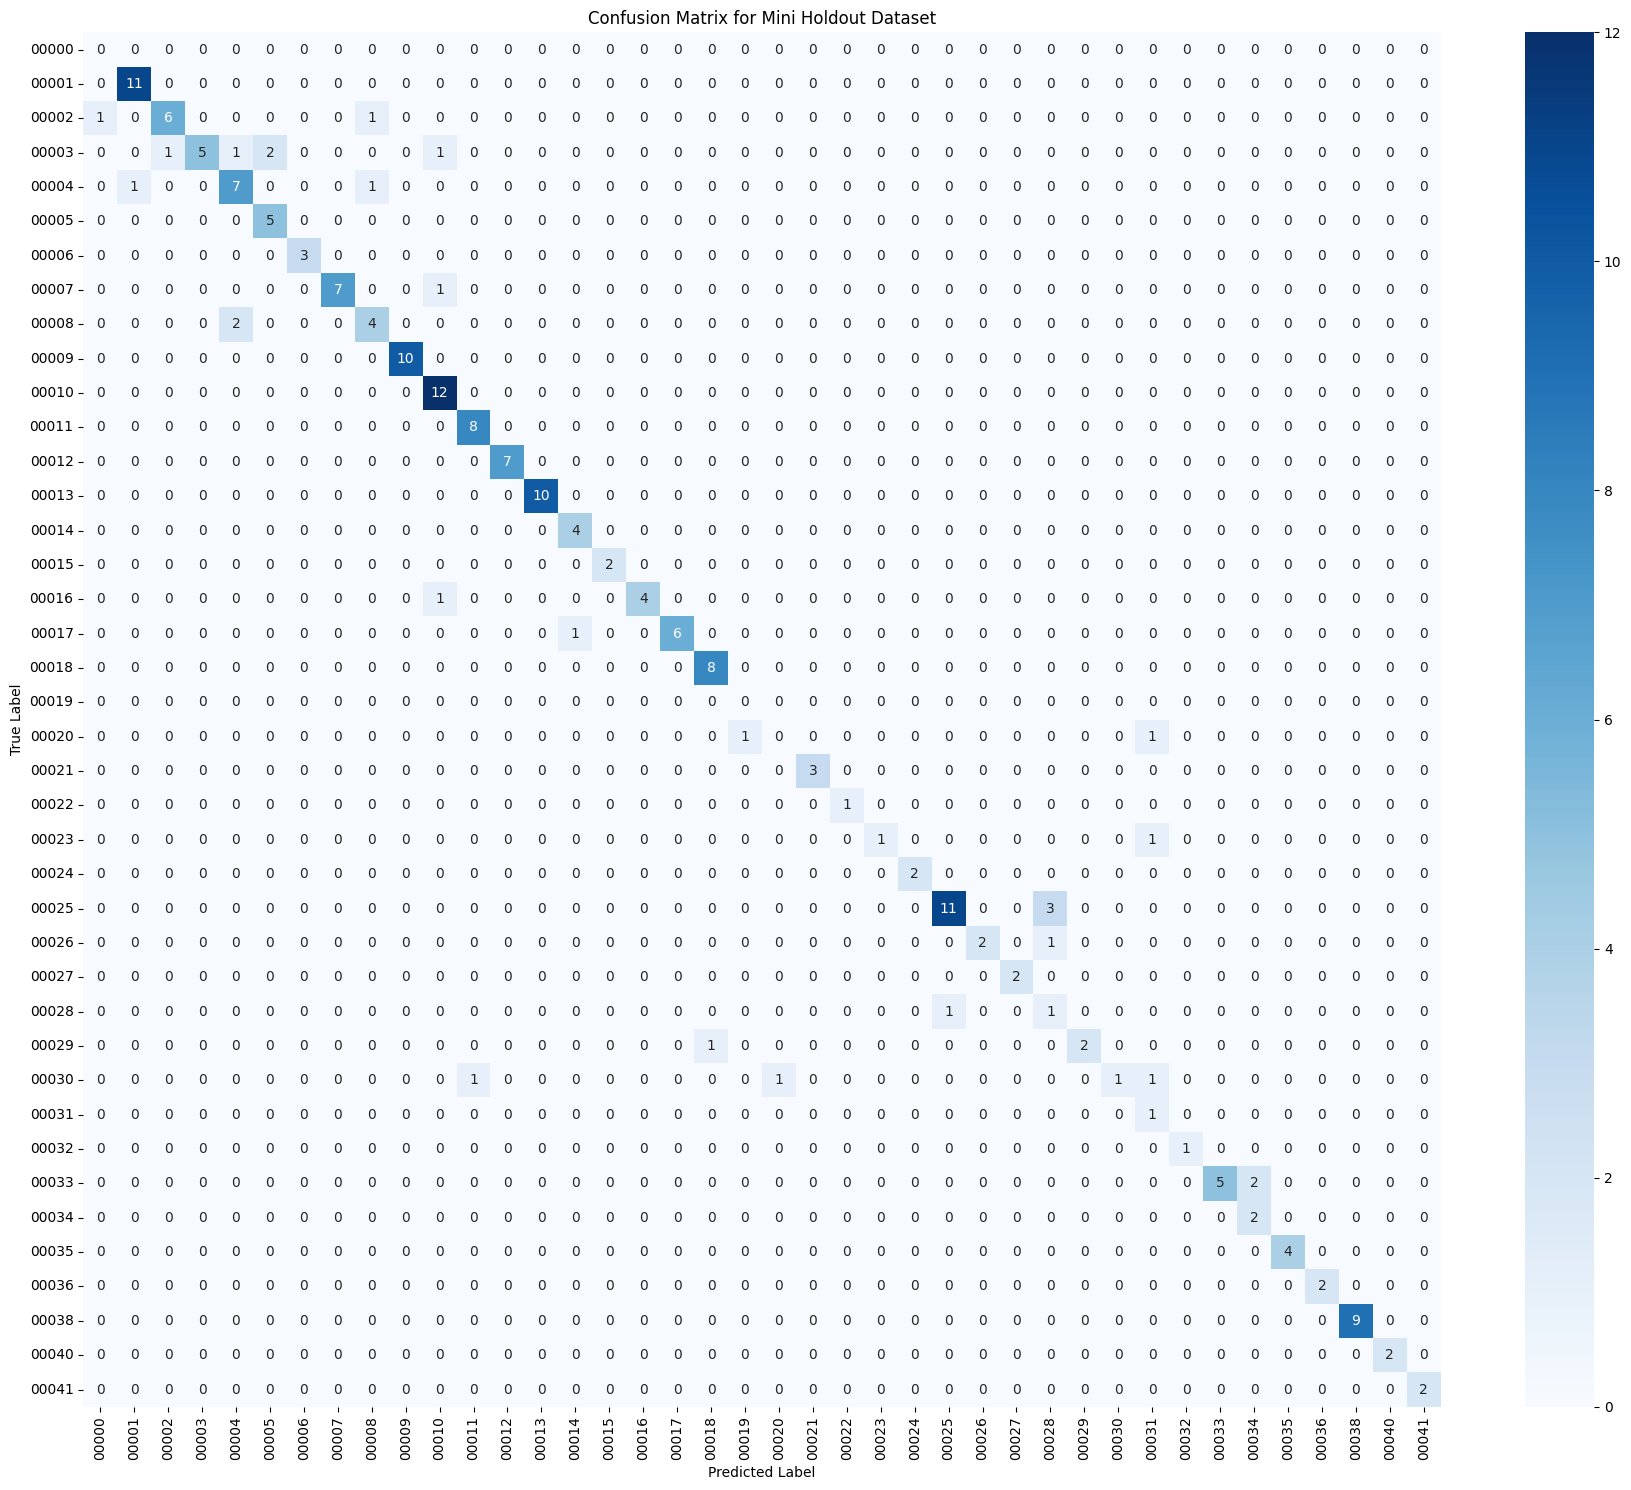

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_a   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

Total misclassified images: 28


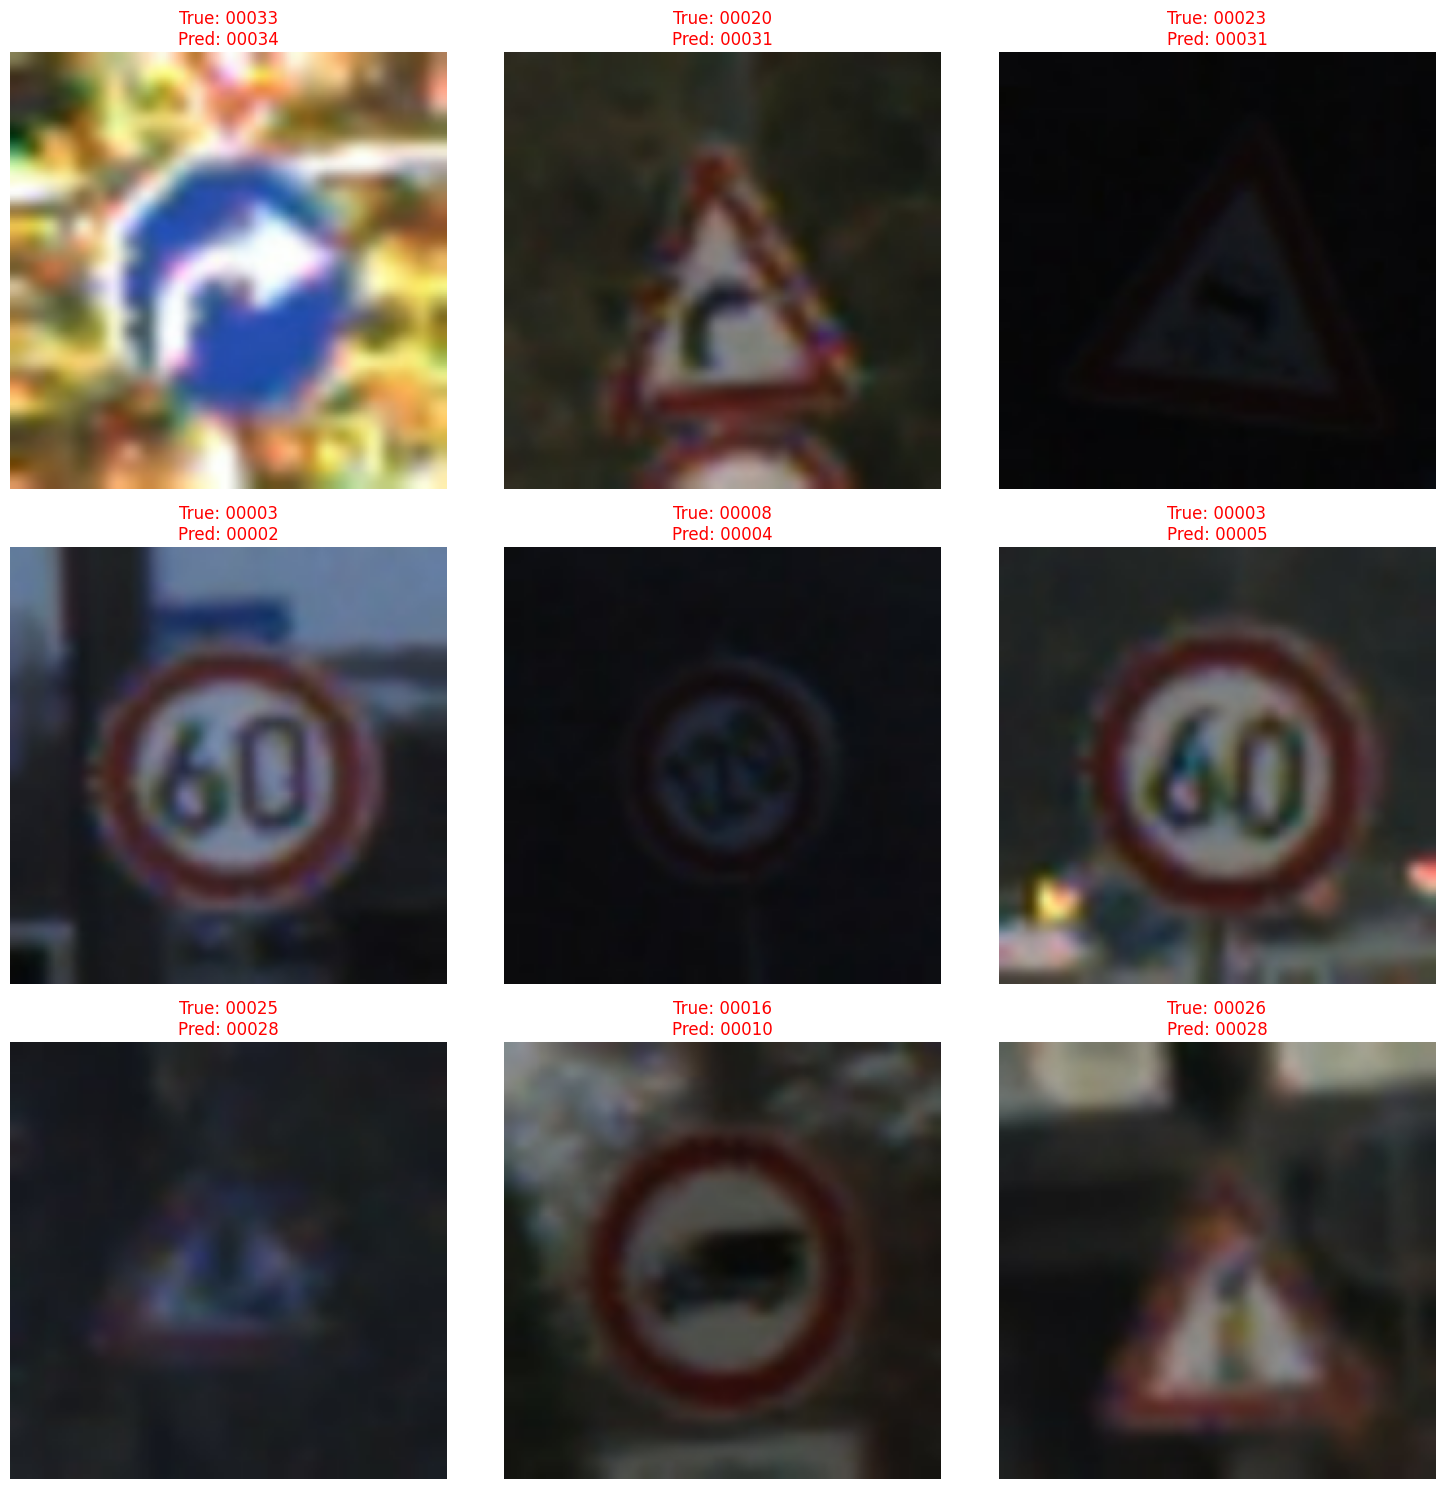

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Find indices where predictions do not match true labels
misclassified_indices = np.where(true_labels != predictions)[0]

print(f"Total misclassified images: {len(misclassified_indices)}")

# Display a subset of misclassified images (e.g., the first 9)
num_to_display = min(len(misclassified_indices), 9)

plt.figure(figsize=(15, 15))
for i in range(num_to_display):
    idx = misclassified_indices[i]
    image_path = test_image_paths[idx]
    true_label_idx = true_labels[idx]
    predicted_label_idx = predictions[idx]

    # Load and preprocess the image for display
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img.numpy().astype("uint8") # Convert to uint8 for matplotlib display

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(f"True: {report_target_names[true_label_idx]}\nPred: {report_target_names[predicted_label_idx]}",
              color='red')
    plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_b   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

# MobileNetB0

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ─────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 43
DATASET_DIR = "/content/training"
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

# ── 1) RECOLECTAR RUTAS Y LABELS ───────────────────────────────────────
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}

image_paths, labels = [], []
for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels      = np.array(labels)
print(f"Total imágenes: {len(image_paths)} | Clases: {len(class_names)}")

# ── 2) SPLIT ESTRATIFICADO ─────────────────────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels          # ✅ garantiza proporción por clase
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# ── 3) PREPROCESAMIENTO ────────────────────────────────────────────────
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    # MobileNetV2 espera [-1, 1] — importante para transfer learning
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    return image, label

def augment(image, label):
    # Solo augmentaciones válidas para señales de tránsito
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # ❌ Sin flip horizontal — cambia el significado de la señal
    return image, label

# ── 4) PIPELINES TF.DATA ───────────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)

# ── 5) CLASS WEIGHTS ───────────────────────────────────────────────────
cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(cw_array))

# ── 6) FUNCIÓN PARA CONSTRUIR MODELO ───────────────────────────────────
def build_model():
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False   # Congelado en Fase 1

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inputs, outputs), base_model

# ── 7) FUNCIÓN DE EVALUACIÓN COMPLETA ─────────────────────────────────
def evaluate_model(model, dataset, labels_true, title="Evaluación"):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(classification_report(labels_true, y_pred,
                                 target_names=class_names, digits=3))

    f1_macro    = f1_score(labels_true, y_pred, average="macro")
    f1_weighted = f1_score(labels_true, y_pred, average="weighted")
    print(f"  Macro F1:    {f1_macro:.4f}")
    print(f"  Weighted F1: {f1_weighted:.4f}")

    # Confusion matrix
    cm = confusion_matrix(labels_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.ylabel("Real"); plt.xlabel("Predicho")
    plt.tight_layout(); plt.show()

    return f1_macro, f1_weighted

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO A: Sin class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🔵 EXPERIMENTO A: Sin class_weight")
model_a, base_a = build_model()

# Fase 1
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

# Fase 2 — fine-tuning
base_a.trainable = True
for layer in base_a.layers[:-20]:
    layer.trainable = False

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_a, f1_w_a = evaluate_model(model_a, val_ds, val_labels, "Sin class_weight")

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO B: Con class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🟠 EXPERIMENTO B: Con class_weight")
model_b, base_b = build_model()

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,       # ✅ única diferencia
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

base_b.trainable = True
for layer in base_b.layers[:-20]:
    layer.trainable = False

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_b, f1_w_b = evaluate_model(model_b, val_ds, val_labels, "Con class_weight")

# ── RESUMEN COMPARATIVO ────────────────────────────────────────────────
print("\n" + "="*50)
print("  RESUMEN COMPARATIVO")
print("="*50)
print(f"  Sin class_weight → Macro F1: {f1_macro_a:.4f} | Weighted F1: {f1_w_a:.4f}")
print(f"  Con class_weight → Macro F1: {f1_macro_b:.4f} | Weighted F1: {f1_w_b:.4f}")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_a   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_b   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

# ResNetB0

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ─────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16        # Menor que MobileNet por el tamaño de ResNet
NUM_CLASSES = 43
DATASET_DIR = "/content/training"
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

# ── 1) RECOLECTAR RUTAS Y LABELS ───────────────────────────────────────
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}

image_paths, labels = [], []
for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels      = np.array(labels)
print(f"Total imágenes: {len(image_paths)} | Clases: {len(class_names)}")

# ── 2) SPLIT ESTRATIFICADO ─────────────────────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# ── 3) PREPROCESAMIENTO ────────────────────────────────────────────────
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet_v2.preprocess_input(image)  # ← ResNet espera [-1, 1]
    return image, label

def augment(image, label):
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # ❌ Sin flip horizontal — cambia el significado de la señal
    return image, label

# ── 4) PIPELINES TF.DATA ───────────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)

# ── 5) CLASS WEIGHTS ───────────────────────────────────────────────────
cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(cw_array))

# ── 6) BUILD MODEL ─────────────────────────────────────────────────────
def build_model():
    base_model = ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inputs, outputs), base_model

# ── 7) EVALUACIÓN COMPLETA ─────────────────────────────────────────────
def evaluate_model(model, dataset, labels_true, title="Evaluación"):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(classification_report(labels_true, y_pred,
                                 target_names=class_names, digits=3))

    f1_macro    = f1_score(labels_true, y_pred, average="macro")
    f1_weighted = f1_score(labels_true, y_pred, average="weighted")
    print(f"  Macro F1:    {f1_macro:.4f}")
    print(f"  Weighted F1: {f1_weighted:.4f}")

    cm = confusion_matrix(labels_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.ylabel("Real"); plt.xlabel("Predicho")
    plt.tight_layout(); plt.show()

    return f1_macro, f1_weighted

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO A: Sin class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🔵 EXPERIMENTO A: Sin class_weight")
model_a, base_a = build_model()

print("  → Fase 1: entrenando cabeza")
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

print("  → Fase 2: fine-tuning")
base_a.trainable = True
for layer in base_a.layers[:-20]:
    layer.trainable = False

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.fit(
    train_ds, validation_data=val_ds, epochs=10,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_a, f1_w_a = evaluate_model(model_a, val_ds, val_labels, "ResNet50V2 — Sin class_weight")

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO B: Con class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🟠 EXPERIMENTO B: Con class_weight")
model_b, base_b = build_model()

print("  → Fase 1: entrenando cabeza")
model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
    ]
)

print("  → Fase 2: fine-tuning")
base_b.trainable = True
for layer in base_b.layers[:-20]:
    layer.trainable = False

model_b.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_b.fit(
    train_ds, validation_data=val_ds, epochs=10,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

f1_macro_b, f1_w_b = evaluate_model(model_b, val_ds, val_labels, "ResNet50V2 — Con class_weight")

# ── RESUMEN COMPARATIVO ────────────────────────────────────────────────
print("\n" + "="*50)
print("  RESUMEN COMPARATIVO — ResNet50V2")
print("="*50)
print(f"  Sin class_weight → Macro F1: {f1_macro_a:.4f} | Weighted F1: {f1_w_a:.4f}")
print(f"  Con class_weight → Macro F1: {f1_macro_b:.4f} | Weighted F1: {f1_w_b:.4f}")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet_v2.preprocess_input(image)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_b   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet_v2.preprocess_input(image)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_a   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns

# ── CONFIG (debe coincidir con tu modelo entrenado) ────────────────────
IMG_SIZE        = 224
BATCH_SIZE      = 32
MINI_HOwLDOUT_DIR     = "/content/mini_holdout"
MINI_HOLDOUT_ANSWERS = "/content/mini_holdout_answers.csv"

# class_names debe ser el mismo que usaste al entrenar
class_names = sorted([
    d for d in os.listdir("/content/training")
    if os.path.isdir(os.path.join("/content/training", d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

# ══════════════════════════════════════════════════════════════════════
# PARTE 1 — MINI HOLDOUT
# ══════════════════════════════════════════════════════════════════════

# ── Leer CSV de respuestas ─────────────────────────────────────────────
answers_df = pd.read_csv(MINI_HOLDOUT_ANSWERS)
print("Columnas del CSV:", answers_df.columns.tolist())
print(answers_df.head())

# Ajusta estos nombres de columna si el CSV los tiene diferentes
IMG_COL   = "Filename"   # ← mayúscula
LABEL_COL = "ClassId"    # ← así exacto

# ── Construir rutas y labels verdaderos ────────────────────────────────
mini_paths  = []
mini_labels = []

for _, row in answers_df.iterrows():
    fpath = os.path.join(MINI_HOLDOUT_DIR, row[IMG_COL])
    if os.path.isfile(fpath):
        mini_paths.append(fpath)
        mini_labels.append(int(row[LABEL_COL]))


mini_paths  = np.array(mini_paths)
mini_labels = np.array(mini_labels)
print(f"\nImágenes encontradas en mini_holdout: {len(mini_paths)}")

# ── Pipeline de inferencia ─────────────────────────────────────────────
def decode_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet_v2.preprocess_input(image)
    # ✅ Cambia esto según el modelo que estés evaluando:
    # EfficientNet  → sin preprocess (comentar la línea de abajo)
    # MobileNetV2   → tf.keras.applications.mobilenet_v2.preprocess_input(image)
    # ResNet50V2    → tf.keras.applications.resnet_v2.preprocess_input(image)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
mini_ds = (
    tf.data.Dataset.from_tensor_slices((mini_paths, mini_labels))
    .map(decode_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# ── Elegir modelo a evaluar ────────────────────────────────────────────
# Cambia model_a o model_b según cuál quieras evaluar
model_to_eval = model_b   # ← CAMBIA AQUÍ

# ── Predicciones ───────────────────────────────────────────────────────
y_probs = model_to_eval.predict(mini_ds, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)

# ── Métricas ───────────────────────────────────────────────────────────
print("\n" + "="*50)
print("  MINI HOLDOUT — Resultados")
print("="*50)
print(classification_report(mini_labels, y_pred,
                             labels=list(range(NUM_CLASSES)),  # ← agrega esto
                             target_names=class_names, digits=3))
f1_macro    = f1_score(mini_labels, y_pred, average="macro")
f1_weighted = f1_score(mini_labels, y_pred, average="weighted")
accuracy    = np.mean(y_pred == mini_labels)

print(f"  Accuracy:    {accuracy:.4f}")
print(f"  Macro F1:    {f1_macro:.4f}")
print(f"  Weighted F1: {f1_weighted:.4f}")

# ── Confusion Matrix ───────────────────────────────────────────────────
cm = confusion_matrix(mini_labels, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — Mini Holdout")
plt.ylabel("Real"); plt.xlabel("Predicho")
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# PARTE 2 — VER IMÁGENES DONDE FALLÓ EL MODELO
# ══════════════════════════════════════════════════════════════════════

# ── Identificar errores ────────────────────────────────────────────────
error_mask   = y_pred != mini_labels
error_paths  = mini_paths[error_mask]
error_true   = mini_labels[error_mask]
error_pred   = y_pred[error_mask]
error_conf   = y_probs[error_mask].max(axis=1)   # confianza del modelo al equivocarse

print(f"\nTotal errores: {error_mask.sum()} / {len(mini_labels)}")
print(f"Clases con más errores:")
from collections import Counter
error_classes = Counter([index_to_class[l] for l in error_true])
for cls, count in error_classes.most_common(10):
    print(f"  {cls}: {count} errores")

# ── Visualizar imágenes fallidas ───────────────────────────────────────
def show_failures(paths, true_labels, pred_labels, confidences,
                  max_images=20, cols=5):
    n    = min(len(paths), max_images)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for i in range(n):
        img = mpimg.imread(paths[i])
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = index_to_class[true_labels[i]]
        pred_name = index_to_class[pred_labels[i]]
        axes[i].set_title(
            f"✅ {true_name}\n❌ {pred_name}\nconf: {confidences[i]:.2f}",
            fontsize=7,
            color="red"
        )

    # Ocultar ejes sobrantes
    for j in range(n, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Imágenes donde falló el modelo ({n} de {len(paths)})",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_failures(error_paths, error_true, error_pred, error_conf, max_images=20)

# ── Ver fallos por clase específica ───────────────────────────────────
def show_failures_for_class(class_name, max_images=10):
    """Muestra solo los errores de una clase en particular."""
    class_idx = class_to_index[class_name]
    mask = (error_true == class_idx)
    if mask.sum() == 0:
        print(f"No hubo errores en la clase '{class_name}' ✅")
        return
    show_failures(
        error_paths[mask], error_true[mask],
        error_pred[mask],  error_conf[mask],
        max_images=max_images
    )

# Ejemplo de uso — cambia el nombre de clase según tu dataset:
# show_failures_for_class("speed_80")
# show_failures_for_class("Warning_bikes")


FileNotFoundError: [Errno 2] No such file or directory: '/content/training'

In [ ]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIG ─────────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 16        # Menor que MobileNet por el tamaño de ResNet
NUM_CLASSES = 43
DATASET_DIR = "/content/training"
SEED        = 42
AUTOTUNE    = tf.data.AUTOTUNE

# ── 1) RECOLECTAR RUTAS Y LABELS ───────────────────────────────────────
class_names = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])
class_to_index = {name: i for i, name in enumerate(class_names)}

image_paths, labels = [], []
for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for fname in os.listdir(class_dir):
        fpath = os.path.join(class_dir, fname)
        if os.path.isfile(fpath):
            image_paths.append(fpath)
            labels.append(class_to_index[class_name])

image_paths = np.array(image_paths)
labels      = np.array(labels)
print(f"Total imágenes: {len(image_paths)} | Clases: {len(class_names)}")

# ── 2) SPLIT ESTRATIFICADO ─────────────────────────────────────────────
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")

# ── 3) PREPROCESAMIENTO ────────────────────────────────────────────────
def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet_v2.preprocess_input(image)  # ← ResNet espera [-1, 1]
    return image, label

def augment(image, label):
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    # ❌ Sin flip horizontal — cambia el significado de la señal
    return image, label

# ── 4) PIPELINES TF.DATA ───────────────────────────────────────────────
def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_paths, train_labels, training=True)
val_ds   = make_dataset(val_paths,   val_labels,   training=False)

# ── 5) CLASS WEIGHTS ───────────────────────────────────────────────────
cw_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(cw_array))

# ── 6) BUILD MODEL ─────────────────────────────────────────────────────
def build_model():
    base_model = ResNet50V2(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = False

    inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base_model(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dropout(0.3)(x)
    x       = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    return models.Model(inputs, outputs), base_model

# ── 7) EVALUACIÓN COMPLETA ─────────────────────────────────────────────
def evaluate_model(model, dataset, labels_true, title="Evaluación"):
    y_pred_probs = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    print(f"\n{'='*50}")
    print(f"  {title}")
    print(f"{'='*50}")
    print(classification_report(labels_true, y_pred,
                                 target_names=class_names, digits=3))

    f1_macro    = f1_score(labels_true, y_pred, average="macro")
    f1_weighted = f1_score(labels_true, y_pred, average="weighted")
    print(f"  Macro F1:    {f1_macro:.4f}")
    print(f"  Weighted F1: {f1_weighted:.4f}")

    cm = confusion_matrix(labels_true, y_pred)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.ylabel("Real"); plt.xlabel("Predicho")
    plt.tight_layout(); plt.show()

    return f1_macro, f1_weighted

# ══════════════════════════════════════════════════════════════════════
# EXPERIMENTO A: Sin class_weight
# ══════════════════════════════════════════════════════════════════════
print("\n🔵 EXPERIMENTO A: Sin class_weight")
model_a, base_a = build_model()

print("  → Fase 1: entrenando cabeza")
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("  → Fase 2: fine-tuning")
base_a.trainable = True
for layer in base_a.layers[:-20]:
    layer.trainable = False

model_a.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_a.summary()

Total imágenes: 39209 | Clases: 43
Train: 31367 | Val: 7842

🔵 EXPERIMENTO A: Sin class_weight
  → Fase 1: entrenando cabeza
  → Fase 2: fine-tuning


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,840,811 (90.95 MB)

 Trainable params: 8,151,595 (31.10 MB)

 Non-trainable params: 15,689,216 (59.85 MB)